# 3. Giorni di superamento delle soglie UE 2030
Calcolo per ciascuna stazione/provincia del numero di giorni di superamento delle soglie sulla protezione della salute umana previste dalla **Direttiva UE 2024/2881** (vincolante dal 1° gennaio 2030), applicate su 6 inquinanti (NO2, SO2, CO, O3, PM10, PM2.5), per valutare quanto lavoro resta da fare per raggiungere la conformità.

Soglie utilizzate (max 18 superamenti/anno per ciascun inquinante):

| Inquinante | Soglia |
|---|---|
| PM10 | media giornaliera 45 μg/m³ |
| PM2.5 | media giornaliera 25 μg/m³ |
| NO2 | media giornaliera 50 μg/m³ |
| Ozono | 120 μg/m³ (approssimazione su media giornaliera 24h, in luogo della media mobile massima su 8h prevista dalla normativa) |
| SO2 | 50 μg/m³ |
| CO | 4 mg/m³ |Calcolo dei giorni di superamento delle soglie limite per la protezione della salute umana, secondo la nuova direttiva UE da raggiungere entro l' 1 gennaio 2030

In [ ]:
import geopandas as gpd
import h3pandas
from shapely.geometry import Point, Polygon
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importazione e pulizia dati

In [2]:
#importazione dati
dati = pd.read_csv("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Dati_sensori_aria_2025.csv")
stazioni = gpd.read_file("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Stazioni qualità dell aria_20260826/geo_export_1e1f2c5a-263d-4a72-908d-7477842f54c0.shp")
province = gpd.read_file("/Users/giulia/Documents/geopandas/Air-quality-Lombardy-2025/data/Limiti amministrativi Province 2020 con aggiornamenti DbT_PGT_20260826/geo_export_97ffb683-dd2e-40cd-b28e-c03e599be95f.shp")

In [13]:
#pulizia dati di qualità dell'aria, delle stazioni e delle province
import functions as f
dati_puliti = f.pulizia_dati(dati)
stazioni_pulite = f.pulizia_stazioni(stazioni)
province = province.to_crs("EPSG:7791")
province = province.rename(columns={'sigla': 'provincia'})

# Media giornaliera per sensore

In [4]:
#calcolo della media giornaliera per sensore
dati_giornalieri = dati_puliti.groupby(["idsensore", dati_puliti["Data"].dt.date])["Valore"].mean().reset_index()
dati_giornalieri.columns = ["idsensore", "Data", "Valore_medio"]

# Merge stazioni e dati

In [21]:
# Merge stazioni e dati 
dati_stazioni_giornalieri = pd.merge(
    dati_giornalieri, stazioni_pulite, on='idsensore', how='left'
)

In [22]:
dati_stazioni_giornalieri["Data"] = pd.to_datetime(dati_stazioni_giornalieri["Data"], format="mixed", dayfirst=True)

# Soglie previste dalla Direttiva UE 2024/2881

In [26]:
#valori limite giornalieri da non superare più di 18 volte all'anno
soglie = {
    'Particelle sospese PM2.5': 25, #μg/m3
    'PM10 (SM2005)': 45, #μg/m3
    'Biossido di Azoto': 50, #μg/m3
    'Biossido di Zolfo': 50, #μg/m3
    'Monossido di Carbonio': 4, #mg/m3
    'Ozono': 120,  ##μg/m3 - approssimazione: media giornaliera 24h invece di max mobile 8h
}

In [27]:
#selezione degli inquinanti da analizzare ('Particelle sospese PM2.5','PM10 (SM2005)','Biossido di Azoto','Biossido di Zolfo','Monossido di Carbonio','Ozono')
dati_stazioni_giornalieri_filtrati = dati_stazioni_giornalieri[dati_stazioni_giornalieri['inquinante'].isin(soglie.keys())]

# Calcolo dei giorni di superamento delle soglie

In [28]:
#valore massimo osservato per ciascun inquinante
dati_stazioni_giornalieri_filtrati[dati_stazioni_giornalieri_filtrati['inquinante'].isin(soglie.keys())].groupby('inquinante')['Valore_medio'].max()

inquinante
Biossido di Azoto            89.558824
Biossido di Zolfo            13.504167
Monossido di Carbonio         2.900000
Ozono                       191.587500
PM10 (SM2005)               184.000000
Particelle sospese PM2.5    121.000000
Name: Valore_medio, dtype: float64

In [29]:
#aggiunta della colonna soglia e del flag di superamento
dati_stazioni_giornalieri_filtrati['soglia'] = dati_stazioni_giornalieri_filtrati['inquinante'].map(soglie)
dati_stazioni_giornalieri_filtrati['supera'] = dati_stazioni_giornalieri_filtrati['Valore_medio'] > dati_stazioni_giornalieri_filtrati['soglia']

In [32]:
#conteggio dei giorni di superamento per stazione per ciascun inquinante
giorni_per_stazione = (
    dati_stazioni_giornalieri_filtrati.groupby(['idstazione', 'inquinante']).size().unstack(fill_value=0)
)

Text(0.5, 1.0, 'Giorni di superamento della soglia per stazione e inquinante')

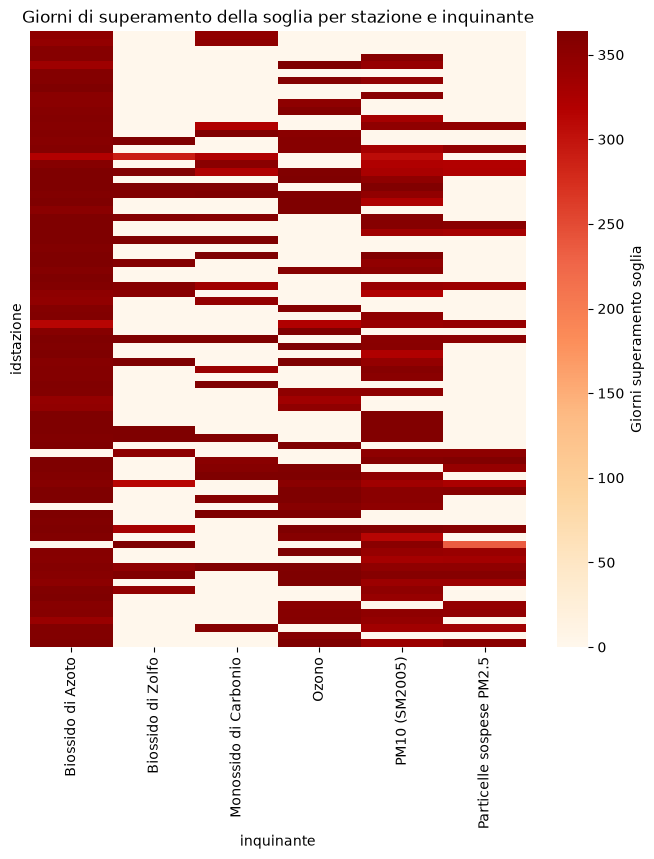

In [ ]:
#heatmap del numero di giorni di superamento per stazione e inquinante
plt.figure(figsize=(8, 8))
sns.heatmap(giorni_per_stazione, cmap='OrRd', fmt='.0f', 
            cbar_kws={'label': 'Giorni superamento soglia'},
            yticklabels=False)
plt.title('Giorni di superamento della soglia per stazione e inquinante')

Dal grafico si intuisce che quando la soglia viene superata per una stazione, avviene per più di 200 giorni all'anno.

In [ ]:
#elenco numero giorni di superamento soglie inquinante per stazione
giorni_per_stazione_inquinante = (
    giorni_per_stazione
    .stack()
    .reset_index()
    .rename(columns={0: 'giorni_superamento'})
    .fillna(0)
)
giorni_per_stazione_inquinante["giorni_superamento"] = giorni_per_stazione_inquinante["giorni_superamento"].astype(int)

,idstazione,inquinante,giorni_superamento
0,501.0,Biossido di Azoto,350
1,501.0,Biossido di Zolfo,0
2,501.0,Monossido di Carbonio,348
3,501.0,Ozono,0
4,501.0,PM10 (SM2005),0
...,...,...,...
481,1297.0,Biossido di Zolfo,0
482,1297.0,Monossido di Carbonio,0
483,1297.0,Ozono,364
484,1297.0,PM10 (SM2005),339


In [47]:
#stazioni che misurano un superamento della soglia di un inquinante più di 18 volte
stazioni_non_conformi = giorni_per_stazione_inquinante[giorni_per_stazione_inquinante['giorni_superamento']>18]
stazioni_non_conformi

,idstazione,inquinante,giorni_superamento
0,501.0,Biossido di Azoto,350
2,501.0,Monossido di Carbonio,348
6,504.0,Biossido di Azoto,346
8,504.0,Monossido di Carbonio,351
12,514.0,Biossido di Azoto,357
...,...,...,...
477,1274.0,Ozono,358
480,1297.0,Biossido di Azoto,362
483,1297.0,Ozono,364
484,1297.0,PM10 (SM2005),339


245 sensori su 486 superano la soglia più di 18 volte all'anno

In [38]:
#min numero di volte che un inquinante supera la soglia in 1 anno (>18 volte)
stazioni_non_conformi.groupby('inquinante')['giorni_superamento'].min()

inquinante
Biossido di Azoto           314
Biossido di Zolfo           291
Monossido di Carbonio       321
Ozono                       321
PM10 (SM2005)               306
Particelle sospese PM2.5    235
Name: giorni_superamento, dtype: int64

Conferma che quando la soglia viene superata, avviene per almeno 235 giorni all'anno.

# Stazioni non conformi per provincia

In [49]:
#merge stazioni
giorni_per_stazione_inquinante = giorni_per_stazione_inquinante.merge(
    stazioni_pulite[['idstazione', 'nomestazio', 'provincia', 'lat', 'lng', 'geometry']].drop_duplicates(),
    on='idstazione'
)

In [50]:
#merge stazioni
stazioni_non_conformi = stazioni_non_conformi.merge(
    stazioni_pulite[['idstazione', 'nomestazio', 'provincia', 'lat', 'lng', 'geometry']].drop_duplicates(),
    on='idstazione'
)

In [52]:
#stazioni non conformi per provincia-inquinante
stazioni_non_conformi_provincia = (
    stazioni_non_conformi
    .groupby(['provincia', 'inquinante'])['idstazione']
    .nunique()
    .reset_index(name='n_stazioni_non_conformi')
)

In [53]:
#stazioni totali per provincia
stazioni_totali_provincia = dati_stazioni_giornalieri_filtrati.groupby('provincia')['idstazione'].nunique()
stazioni_totali_provincia

provincia
BG     9
BS     8
CO     2
CR     6
LC     7
LO     7
MB     2
MI    16
MN     7
PV     8
SO     4
VA     5
Name: idstazione, dtype: int64

In [54]:
#pivot table
pivot_table = stazioni_non_conformi_provincia.pivot(
    index='provincia', columns='inquinante', values='n_stazioni_non_conformi'
).fillna(0)
pivot_table_percentuale = pivot_table.div(stazioni_totali_provincia, axis=0) * 100
pivot_table_percentuale

inquinante,Biossido di Azoto,Biossido di Zolfo,Monossido di Carbonio,Ozono,PM10 (SM2005),Particelle sospese PM2.5
provincia,,,,,,
BG,100.000000,33.333333,33.333333,33.333333,77.777778,44.444444
BS,87.500000,12.500000,12.500000,37.500000,62.500000,12.500000
CO,100.000000,50.000000,50.000000,100.000000,100.000000,50.000000
CR,100.000000,16.666667,16.666667,66.666667,83.333333,50.000000
LC,85.714286,14.285714,28.571429,71.428571,71.428571,28.571429
LO,100.000000,28.571429,14.285714,42.857143,71.428571,28.571429
MB,100.000000,50.000000,0.000000,50.000000,100.000000,50.000000
MI,100.000000,6.250000,31.250000,37.500000,37.500000,12.500000
MN,100.000000,42.857143,42.857143,42.857143,85.714286,57.142857


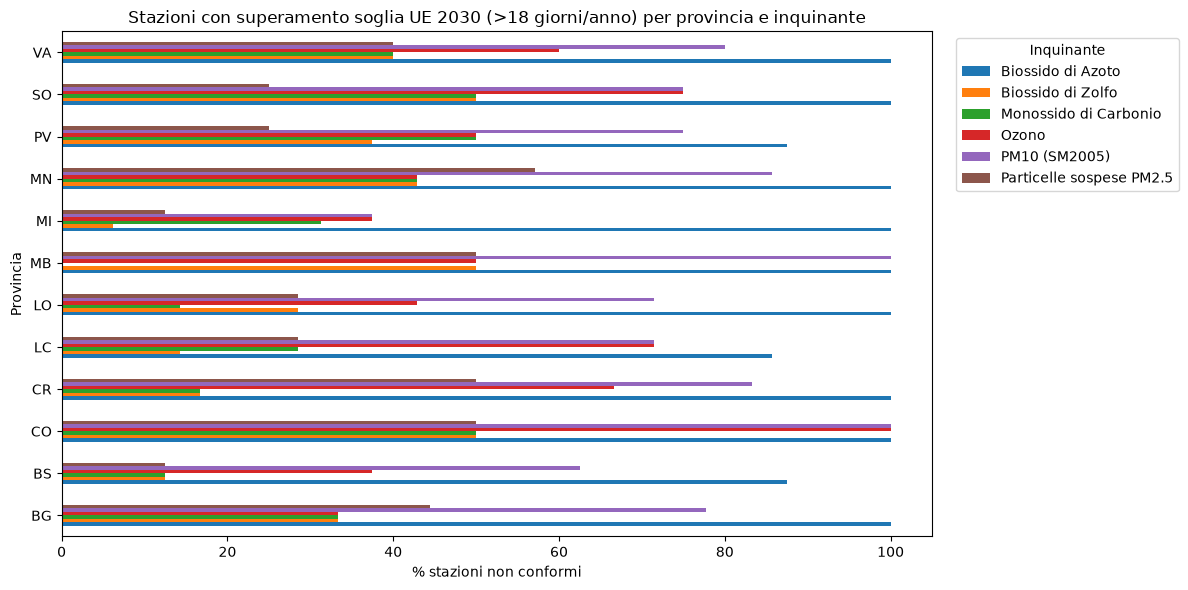

In [55]:
#bar plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
pivot_table_percentuale.plot(kind='barh', ax=ax)

ax.set_xlabel('% stazioni non conformi')
ax.set_ylabel('Provincia')
ax.set_title('Stazioni con superamento soglia UE 2030 (>18 giorni/anno) per provincia e inquinante')
ax.legend(title='Inquinante', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Il Biossido di Azoto (NO2) è l'inquinante più critico: quasi tutte le province hanno il 100% delle stazioni non conformi rispetto alla soglia 2030.

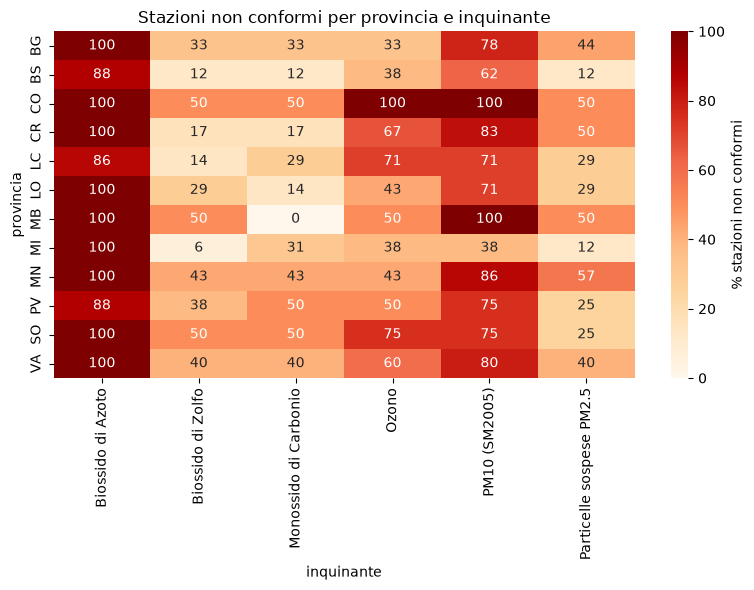

In [56]:
#heatmap stazioni non conformi per provincia e inquinante
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_table_percentuale, annot=True, fmt='.0f', cmap='OrRd', cbar_kws={'label': '% stazioni non conformi'})
ax.set_title('Stazioni non conformi per provincia e inquinante')
plt.tight_layout()
plt.show()

tutte le stazioni della provincia di Como suprano le soglie UE del Biossido di Azoto, Ozono e PM10.